<a href="https://colab.research.google.com/github/robyperez/IA/blob/main/Parcial_II_algoritmos_Gen%C3%A9ticos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Parcial II- algoritmos Genéticos.**

## Integrantes:
1. Roby Anderson Pérez Hoyos
2. Angel David Caicedo Anchico

# PARCIAL II - INTELIGENCIA ARTIFICIAL: OPTIMIZACIÓN DE FLOW SHOP CON ALGORITMOS GENÉTICOS

## Introducción

Este notebook aborda un problema clásico de planificación de la producción conocido como **Flow Shop Scheduling Problem (FSP)**. El objetivo principal es aplicar **Algoritmos Genéticos (AG)**, una técnica de Inteligencia Artificial inspirada en la evolución natural, para encontrar una solución óptima o cercana a la óptima para este problema.

## Descripción del Problema: Flow Shop

En un entorno Flow Shop:

1.  Hay un conjunto de **`n` tareas** (o trabajos) que deben ser procesadas.
2.  Hay un conjunto de **`m` máquinas** disponibles.
3.  **Todas las tareas siguen la misma secuencia de máquinas:** primero pasan por la Máquina 1, luego por la Máquina 2, y así sucesivamente hasta la Máquina `m`.
4.  Cada tarea `i` tiene un **tiempo de procesamiento** conocido `T_ij` en cada máquina `j`.
5.  Una máquina solo puede procesar **una tarea a la vez**.
6.  Una tarea solo puede ser procesada por **una máquina a la vez**.
7.  Las operaciones **no pueden ser interrumpidas** una vez iniciadas.

El principal desafío en el FSP es determinar el **orden o secuencia** en que las `n` tareas deben ser introducidas en la primera máquina. Esta secuencia inicial afectará directamente los tiempos de espera de las tareas en las máquinas subsiguientes y, por lo tanto, el tiempo total para completar *todas* las tareas.

## Objetivo del Ejercicio

El objetivo específico de este ejercicio es:

**Utilizar un Algoritmo Genético implementado con la biblioteca `DEAP` de Python para encontrar la secuencia de procesamiento de tareas que minimice el *Makespan*.**

*   **Makespan (Cmax):** Es el tiempo total transcurrido desde que la primera tarea comienza en la primera máquina hasta que la última tarea finaliza en la última máquina. Minimizar el Makespan equivale a completar todo el lote de trabajos en el menor tiempo posible, lo cual es un objetivo común de eficiencia en producción.

## Metodología

1.  **Representación:** Cada posible solución (individuo en el AG) será una permutación de las `n` tareas, representando el orden de procesamiento.
2.  **Función de Aptitud (Fitness):** Se calculará el Makespan para cada secuencia candidata. El valor del Makespan será la medida de aptitud, y el objetivo será minimizarlo.
3.  **Operadores Genéticos:** Se emplearán operadores de cruce y mutación adecuados para permutaciones (como PMX y Shuffle Indexes) y un método de selección (como Tournament Selection) para evolucionar la población de secuencias candidatas a lo largo de varias generaciones.
4.  **Resultado:** El algoritmo devolverá la mejor secuencia encontrada y su Makespan asociado, junto con visualizaciones que ilustren el proceso y la solución.

Este notebook guiará paso a paso a través de la implementación, ejecución y análisis de los resultados del algoritmo genético aplicado al problema Flow Shop definido en el ejemplo proporcionado.

In [ ]:
#@title 1. Instalación e Importaciones

# Instalar DEAP si no está presente (necesario en Google Colab)
!pip install deap -q

import random
import numpy as np
import matplotlib.pyplot as plt
from deap import base, creator, tools, algorithms
import time # Para medir tiempo si fuera necesario

print("Bibliotecas importadas y DEAP instalado.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.6/135.6 kB 3.1 MB/s eta 0:00:00
Bibliotecas importadas y DEAP instalado.


##Sección 2: Definición del Problema y Datos de Entrada
Aquí definimos los parámetros del problema específico que se muestra en el PDF (5 tareas, 4 máquinas) y sus tiempos de procesamiento.

In [ ]:
#@title 2. Definición del Problema y Datos de Entrada

# --- Parámetros del Problema (Basado en el ejemplo del PDF) ---
NUM_TAREAS = 5  # Número de tareas (n)
NUM_MAQUINAS = 4 # Número de máquinas (m)

# --- Tiempos de Procesamiento (Matriz T_ij) ---
# Extraído de la "Tabla de tiempos" del PDF.
# Formato: tiempos_procesamiento[tarea_i][maquina_j]
# IMPORTANTE: Usaremos índices 0-based para tareas (0 a n-1) y máquinas (0 a m-1)
# Tarea 1 del PDF -> Índice 0, Tarea 2 -> Índice 1, etc.
# Maquina M1 del PDF -> Índice 0, Maquina M2 -> Índice 1, etc.

#             M1 M2 M3 M4 (Índices 0, 1, 2, 3)
tiempos_procesamiento = [
    [5, 4, 4, 3], # Tarea 1 (Índice 0)
    [5, 4, 4, 6], # Tarea 2 (Índice 1)
    [3, 2, 2, 3], # Tarea 3 (Índice 2)
    [6, 4, 4, 2], # Tarea 4 (Índice 3)
    [3, 4, 1, 5]  # Tarea 5 (Índice 4)
]

# Convertir a un array de NumPy para facilidad de uso (opcional pero recomendado)
tiempos_procesamiento = np.array(tiempos_procesamiento)

# Verificar dimensiones
n_tareas_check, m_maquinas_check = tiempos_procesamiento.shape
assert n_tareas_check == NUM_TAREAS, f"Error: La matriz de tiempos tiene {n_tareas_check} filas, pero se esperaban {NUM_TAREAS} tareas."
assert m_maquinas_check == NUM_MAQUINAS, f"Error: La matriz de tiempos tiene {m_maquinas_check} columnas, pero se esperaban {NUM_MAQUINAS} máquinas."

print(f"--- Configuración del Problema Flow Shop ---")
print(f"Número de Tareas (n): {NUM_TAREAS}")
print(f"Número de Máquinas (m): {NUM_MAQUINAS}")
print(f"\nTiempos de Procesamiento (T_ij):")
# Imprimir de forma más legible, añadiendo 1 a los índices para coincidir con PDF
for i in range(NUM_TAREAS):
    print(f"  Tarea {i+1}: {tiempos_procesamiento[i].tolist()}")
print("-" * 40)

# Guardamos las dimensiones para usarlas más adelante
n = NUM_TAREAS
m = NUM_MAQUINAS

--- Configuración del Problema Flow Shop ---
Número de Tareas (n): 5
Número de Máquinas (m): 4

Tiempos de Procesamiento (T_ij):
  Tarea 1: [5, 4, 4, 3]
  Tarea 2: [5, 4, 4, 6]
  Tarea 3: [3, 2, 2, 3]
  Tarea 4: [6, 4, 4, 2]
  Tarea 5: [3, 4, 1, 5]
----------------------------------------


## Sección 3: Creación de Tipos DEAP y Toolbox Inicial
Configuramos DEAP para nuestro problema: minimización y representación del individuo como una lista (permutación).

In [ ]:
#@title 3. Creación de Tipos DEAP y Toolbox Inicial

# --- Creación de Tipos con DEAP ---
# El objetivo es MINIMIZAR el Makespan.
# Creamos un tipo de Fitness que busca minimizar un único objetivo (weights=(-1.0,))
try:
    creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
    # Creamos el tipo 'Individual'. Será una lista estándar de Python (`list`)
    # que representará la permutación de tareas. Le asociamos el FitnessMin.
    creator.create("Individual", list, fitness=creator.FitnessMin)
    print("Tipos 'FitnessMin' e 'Individual' creados en DEAP.")
except Exception as e:
    print(f"Advertencia: Los tipos DEAP ya existían ({e}). Continuando...")

# --- Creación del Toolbox ---
# El Toolbox contendrá las funciones para generar la población y los operadores genéticos.
toolbox = base.Toolbox()

# --- Inicialización de Individuos y Población ---
# Un individuo es una permutación de los índices de las tareas (de 0 a n-1).
# Usamos random.sample para crear una permutación aleatoria de los índices.
toolbox.register("indices_tareas", random.sample, range(n), n) # Genera una permutación de [0, 1, ..., n-1]

# 'individual': Crea un individuo inicializándolo con la permutación generada por 'indices_tareas'.
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.indices_tareas)

# 'population': Crea una población como una lista de individuos generados por 'individual'.
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

print("Toolbox inicializado.")
print("Funciones para crear individuos (permutación de tareas 0..n-1) y poblaciones registradas.")

# --- Prueba rápida (opcional) ---
# Crear e imprimir un individuo de ejemplo
individuo_ejemplo = toolbox.individual()
print(f"\nIndividuo de ejemplo (secuencia de tareas, índices 0..{n-1}): {individuo_ejemplo}")
# Crear e imprimir una pequeña población de ejemplo
poblacion_ejemplo = toolbox.population(n=3) # Crear población de 3 individuos
print(f"Población de ejemplo (n=3):")
for i, ind in enumerate(poblacion_ejemplo):
    print(f"  Individuo {i}: {ind}")

Tipos 'FitnessMin' e 'Individual' creados en DEAP.
Toolbox inicializado.
Funciones para crear individuos (permutación de tareas 0..n-1) y poblaciones registradas.

Individuo de ejemplo (secuencia de tareas, índices 0..4): [4, 1, 0, 3, 2]
Población de ejemplo (n=3):
  Individuo 0: [1, 0, 2, 3, 4]
  Individuo 1: [3, 2, 4, 0, 1]
  Individuo 2: [1, 0, 2, 3, 4]


## Sección 4: Cálculo del Makespan y Función de Evaluación (Fitness)
Esta sección define la función calcular_makespan que toma una secuencia de tareas (un individuo) y la matriz de tiempos, y devuelve el tiempo de finalización de la última tarea en la última máquina (Makespan). Luego, registraremos esta función como la función evaluate en el toolbox.

In [ ]:
#@title 4. Cálculo del Makespan y Función de Evaluación (Fitness)

def calcular_makespan(secuencia_tareas, tiempos_proc, num_maquinas, num_tareas):
    """
    Calcula el Makespan (Cmax) para una secuencia dada de tareas en un Flow Shop.

    Args:
        secuencia_tareas (list): Una lista representando la permutación de los
                                 índices de las tareas (0 a n-1).
        tiempos_proc (np.array): La matriz NumPy de tiempos de procesamiento (n x m).
        num_maquinas (int): El número de máquinas (m).
        num_tareas (int): El número de tareas (n).

    Returns:
        float: El Makespan (tiempo de finalización de la última tarea en la última máquina).
    """
    # Matriz C para almacenar los tiempos de finalización C(i, j)
    # C[k][j] será el tiempo de finalización de la k-ésima tarea en la secuencia
    # en la máquina j (índices j de 0 a m-1).
    # Usamos num_tareas + 1 filas para facilitar los cálculos basados en 1 (como en PDF)
    # aunque los índices de máquinas van de 0 a m-1.
    C = np.zeros((num_tareas + 1, num_maquinas))

    # Recorrer las tareas en el orden dado por la secuencia_tareas
    for k in range(1, num_tareas + 1): # k es el índice de la posición en la secuencia (1 a n)
        # Obtener el índice real de la tarea (0 a n-1) que está en la posición k
        idx_tarea_actual = secuencia_tareas[k-1]

        # Calcular tiempos de finalización para la tarea actual en cada máquina
        for j in range(num_maquinas): # j es el índice de la máquina (0 a m-1)
            tiempo_proc_actual = tiempos_proc[idx_tarea_actual][j]

            # Calcular C(k, j) basado en las fórmulas (1.1 a 1.4) adaptadas

            # Tiempo de finalización en la máquina anterior (misma tarea k)
            tiempo_fin_maq_anterior = C[k][j-1] if j > 0 else 0
            # Tiempo de finalización en la misma máquina (tarea anterior k-1 en la secuencia)
            tiempo_fin_tarea_anterior = C[k-1][j] if k > 1 else 0

            # Aplicar fórmula C(k, j) = max(C(k-1, j), C(k, j-1)) + T_kj
            C[k][j] = max(tiempo_fin_tarea_anterior, tiempo_fin_maq_anterior) + tiempo_proc_actual

    # El Makespan es el tiempo de finalización de la última tarea (en la posición n)
    # en la última máquina (índice m-1).
    makespan = C[num_tareas][num_maquinas - 1]
    return makespan

# --- Prueba de la función calcular_makespan ---
# Usar la secuencia 1-2-3-4-5 del PDF (índices 0-1-2-3-4)
secuencia_pdf = [0, 1, 2, 3, 4] # Corresponde a Tarea 1, Tarea 2, ..., Tarea 5
makespan_calculado = calcular_makespan(secuencia_pdf, tiempos_procesamiento, m, n)
print(f"--- Prueba de Cálculo del Makespan ---")
print(f"Secuencia de prueba (índices 0..{n-1}): {secuencia_pdf}")
print(f"Makespan calculado: {makespan_calculado}")

# Verificación manual con los cálculos intermedios del PDF (página 3)
# C52 = max(C42,C51) + T52 = max(23,22) + 4 = 27 (Esto es C[5][1] en nuestra matriz 0-based)
# Necesitamos seguir hasta C[5][3] (última tarea, última máquina)
# C13 = C12 + T13 = 9 + 4 = 13
# C23 = max(C13, C22) + T23 = max(13, 14) + 4 = 18
# C33 = max(C23, C32) + T33 = max(18, 16) + 2 = 20
# C43 = max(C33, C42) + T43 = max(20, 23) + 4 = 27
# C53 = max(C43, C52) + T53 = max(27, 27) + 1 = 28
# C14 = C13 + T14 = 13 + 3 = 16
# C24 = max(C14, C23) + T24 = max(16, 18) + 6 = 24
# C34 = max(C24, C33) + T34 = max(24, 20) + 3 = 27
# C44 = max(C34, C43) + T44 = max(27, 27) + 2 = 29
# C54 = max(C44, C53) + T54 = max(29, 28) + 5 = 34  <--- ESTE ES EL MAKESPAN FINAL C[5][3]
# El diagrama Gantt del PDF también termina en 34.
print(f"Makespan esperado según PDF/Gantt: 34.0")
assert makespan_calculado == 34.0, "Error: El cálculo del Makespan no coincide con el ejemplo del PDF."
print("¡Verificación con el ejemplo del PDF exitosa!")
print("-" * 40)

# --- Registro de la Función de Evaluación en el Toolbox ---
# La función de evaluación ('evaluate') simplemente llama a calcular_makespan.
# Debe devolver una tupla, como requiere DEAP.
def evaluate_flowshop(individual):
    """Función de evaluación para DEAP. Calcula el makespan del individuo."""
    # El individuo es la secuencia de tareas
    makespan = calcular_makespan(individual, tiempos_procesamiento, m, n)
    return (makespan,) # Devuelve como tupla

toolbox.register("evaluate", evaluate_flowshop)
print("Función de evaluación 'evaluate_flowshop' (basada en Makespan) registrada.")

# Probar la evaluación con el individuo de ejemplo anterior
makespan_ejemplo, = toolbox.evaluate(individuo_ejemplo) # Desempaquetar la tupla
print(f"\nMakespan evaluado para el individuo {individuo_ejemplo}: {makespan_ejemplo}")

--- Prueba de Cálculo del Makespan ---
Secuencia de prueba (índices 0..4): [0, 1, 2, 3, 4]
Makespan calculado: 34.0
Makespan esperado según PDF/Gantt: 34.0
¡Verificación con el ejemplo del PDF exitosa!
----------------------------------------
Función de evaluación 'evaluate_flowshop' (basada en Makespan) registrada.

Makespan evaluado para el individuo [4, 1, 0, 3, 2]: 32.0


## Explicación del Código `calcular_makespan`

1. **Inicialización:**
Crea una matriz `C` de ceros de tamaño $(n+1) \times m$. Usamos $n+1$ filas para que los índices $k$ (posición en la secuencia) puedan ir de $1$ a $n$, similar a como se razona en el PDF, aunque los índices de las máquinas $j$ van de $0$ a $m-1$.

2. **Bucle de Tareas:**
Itera desde $k = 1$ hasta $n$ (representando la 1ª, 2ª, ..., n-ésima tarea en la secuencia dada).

3. **Índice Real:**
Obtiene el índice real (`idx_tarea_actual`) de la tarea correspondiente a la posición $k$ en la `secuencia_tareas` de entrada.

4. **Bucle de Máquinas:**
Itera desde $j = 0$ hasta $m-1$ (para cada máquina).

5. **Tiempos Anteriores:**
Obtiene los tiempos de finalización relevantes:
* `tiempo_fin_maq_anterior = C[k][j-1]`: Tiempo en que la misma tarea ($k$) terminó en la máquina anterior ($j-1$). Es $0$ si es la primera máquina ($j=0$).
* `tiempo_fin_tarea_anterior = C[k-1][j]`: Tiempo en que la tarea anterior en la secuencia ($k-1$) terminó en la misma máquina ($j$). Es $0$ si es la primera tarea en la secuencia ($k=1$).

6. **Cálculo de C[k][j]:**
Aplica la fórmula **max(tiempo_fin_tarea_anterior, tiempo_fin_maq_anterior) + tiempo_proc_actual**. Esto asegura que la tarea $k$ no empieza en la máquina $j$ hasta que tanto la máquina $j$ esté libre (después de la tarea $k-1$) como la propia tarea $k$ haya terminado en la máquina $j-1$.

7. **Resultado:**
El Makespan final es el valor en $C[n][m-1]$, que es el tiempo de finalización de la n-ésima tarea de la secuencia en la m-ésima máquina.

La prueba con la secuencia `[0, 1, 2, 3, 4]` (1-2-3-4-5 del PDF) da como resultado `34.0`, lo cual coincide con el diagrama de Gantt y los cálculos manuales derivados del PDF, validando la función.

## Sección 5: Registro de Operadores Genéticos
Ahora registramos los operadores de cruce, mutación y selección en el toolbox. Como estamos trabajando con permutaciones, usaremos los mismos operadores que en los ejercicios anteriores.

In [ ]:
#@title 5. Registro de Operadores Genéticos

# --- Cruce (Crossover) ---
# Usamos Partially Matched Crossover (PMX), adecuado para permutaciones.
# Asegura que los hijos también sean permutaciones válidas de las tareas.
toolbox.register("mate", tools.cxPartialyMatched)

# --- Mutación ---
# Usamos Shuffle Indexes Mutation. Intercambia las posiciones de algunos
# índices de tareas dentro del individuo.
# 'indpb' es la probabilidad de que cada índice de tarea sea incluido
# en el grupo de índices a barajar (intercambiar).
toolbox.register("mutate", tools.mutShuffleIndexes, indpb=0.1) # Probabilidad ajustada

# --- Selección ---
# Usamos Selección por Torneo. Se eligen 'tournsize' individuos al azar,
# y el mejor de ellos (menor Makespan) es seleccionado.
toolbox.register("select", tools.selTournament, tournsize=3)

print("Operadores genéticos (mate, mutate, select) registrados en el toolbox.")
print(f"  Cruce: Partially Matched Crossover (PMX)")
print(f"  Mutación: Shuffle Indexes (indpb={toolbox.mutate.keywords['indpb']})") # Muestra la prob. usada
print(f"  Selección: Tournament (tournsize={toolbox.select.keywords['tournsize']})") # Muestra el tamaño del torneo

Operadores genéticos (mate, mutate, select) registrados en el toolbox.
  Cruce: Partially Matched Crossover (PMX)
  Mutación: Shuffle Indexes (indpb=0.1)
  Selección: Tournament (tournsize=3)


## Sección 6: Ejecución del Algoritmo Genético
Esta sección define la función principal que ejecuta el algoritmo genético eaSimple de DEAP, utilizando todos los componentes que hemos configurado (población, evaluación, operadores).

In [ ]:
#@title 6. Ejecución del Algoritmo Genético

def run_ga_flowshop(pop_size=100, ngen=50, cxpb=0.7, mutpb=0.2, seed=None):
    """
    Ejecuta el algoritmo genético estándar (eaSimple) para el problema Flow Shop.

    Args:
        pop_size (int): Tamaño de la población.
        ngen (int): Número máximo de generaciones.
        cxpb (float): Probabilidad de cruce.
        mutpb (float): Probabilidad de mutación.
        seed (int, optional): Semilla para reproducibilidad. Defaults to None.

    Returns:
        tuple: (mejor_individuo, logbook, población_final)
               - mejor_individuo: La mejor secuencia encontrada (lista de índices 0..n-1).
               - logbook: Objeto DEAP con las estadísticas de la evolución.
               - población_final: La lista de individuos al final de la ejecución.
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    # --- Población Inicial ---
    population = toolbox.population(n=pop_size)

    # --- Salón de la Fama (Hall of Fame) ---
    # Guarda el mejor individuo encontrado a lo largo de toda la ejecución.
    hof = tools.HallOfFame(1)

    # --- Estadísticas ---
    # Registra el promedio, mínimo (mejor) y máximo (peor) Makespan en cada generación.
    stats = tools.Statistics(lambda ind: ind.fitness.values[0]) # Accede al valor del Makespan
    stats.register("avg", np.mean)
    stats.register("min", np.min)
    stats.register("max", np.max)

    # --- Ejecución del Algoritmo eaSimple ---
    print(f"\n--- Iniciando Algoritmo Genético (Flow Shop) ---")
    print(f"Parámetros: Población={pop_size}, Generaciones={ngen}, CXPB={cxpb}, MUTPB={mutpb}, Seed={seed}")
    print(f"Objetivo: Minimizar Makespan...")
    print("-" * 60)

    # Ejecutar el algoritmo genético
    final_pop, logbook = algorithms.eaSimple(
        population,
        toolbox,
        cxpb=cxpb,
        mutpb=mutpb,
        ngen=ngen,
        stats=stats,
        halloffame=hof,
        verbose=True # Muestra el progreso
    )

    # --- Resultados ---
    best_individual = hof[0] # El mejor individuo está en el Hall of Fame
    best_fitness = best_individual.fitness.values[0] # Su Makespan

    print("-" * 60)
    print(f"\n--- Ejecución Finalizada ---")
    print(f"Mejor Makespan encontrado: {best_fitness}")
    # Mostrar la secuencia de tareas (sumando 1 a los índices para que sea más legible)
    best_sequence_readable = [i + 1 for i in best_individual]
    print(f"Mejor secuencia de tareas encontrada (Tareas 1..{n}): {best_sequence_readable}")

    return best_individual, logbook, final_pop

# --- Parámetros y Ejecución ---
# Puedes ajustar estos parámetros para experimentar
POPULATION_SIZE = 100  # Tamaño de la población
GENERATIONS = 80      # Número de generaciones
CROSSOVER_PROB = 0.8   # Probabilidad de cruce
MUTATION_PROB = 0.15   # Probabilidad de mutación
RANDOM_SEED = 42       # Semilla para obtener resultados consistentes

# Ejecutar el algoritmo
best_solution_indices, evolution_log, final_population = run_ga_flowshop(
    pop_size=POPULATION_SIZE,
    ngen=GENERATIONS,
    cxpb=CROSSOVER_PROB,
    mutpb=MUTATION_PROB,
    seed=RANDOM_SEED
)


--- Iniciando Algoritmo Genético (Flow Shop) ---
Parámetros: Población=100, Generaciones=80, CXPB=0.8, MUTPB=0.15, Seed=42
Objetivo: Minimizar Makespan...
------------------------------------------------------------
gen	nevals	avg  	min	max
0  	100   	34.44	32 	38 
1  	87    	33.28	32 	38 
2  	84    	32.48	32 	36 
3  	94    	32.25	32 	36 
4  	86    	32.56	32 	38 
5  	85    	32.38	32 	36 
6  	84    	32.32	32 	38 
7  	78    	32.19	32 	38 
8  	87    	32.16	32 	36 
9  	91    	32.2 	32 	36 
10 	81    	32.33	32 	38 
11 	88    	32.13	32 	36 
12 	83    	32.24	32 	38 
13 	80    	32.09	32 	34 
14 	84    	32.19	32 	36 
15 	74    	32.06	32 	34 
16 	87    	32.25	32 	36 
17 	90    	32.2 	32 	36 
18 	83    	32.31	32 	36 
19 	87    	32.12	32 	36 
20 	79    	32.29	32 	36 
21 	84    	32.12	32 	36 
22 	77    	32.18	32 	38 
23 	86    	32.18	32 	36 
24 	92    	32.19	32 	34 
25 	82    	32.3 	32 	38 
26 	87    	32.14	32 	34 
27 	84    	32.29	32 	36 
28 	86    	32.16	32 	36 
29 	79    	32.4 	32 	38 
30 	83  

## Sección 7: Visualización de Resultados
Aquí añadiremos el gráfico de evolución de la aptitud (Makespan) que es estándar y fácil de generar. También incluiremos el código para un gráfico de Gantt básico, aunque crear un Gantt preciso y bonito con Matplotlib puede ser un poco elaborado, haremos una versión funcional.

--- Gráfico de Evolución ---


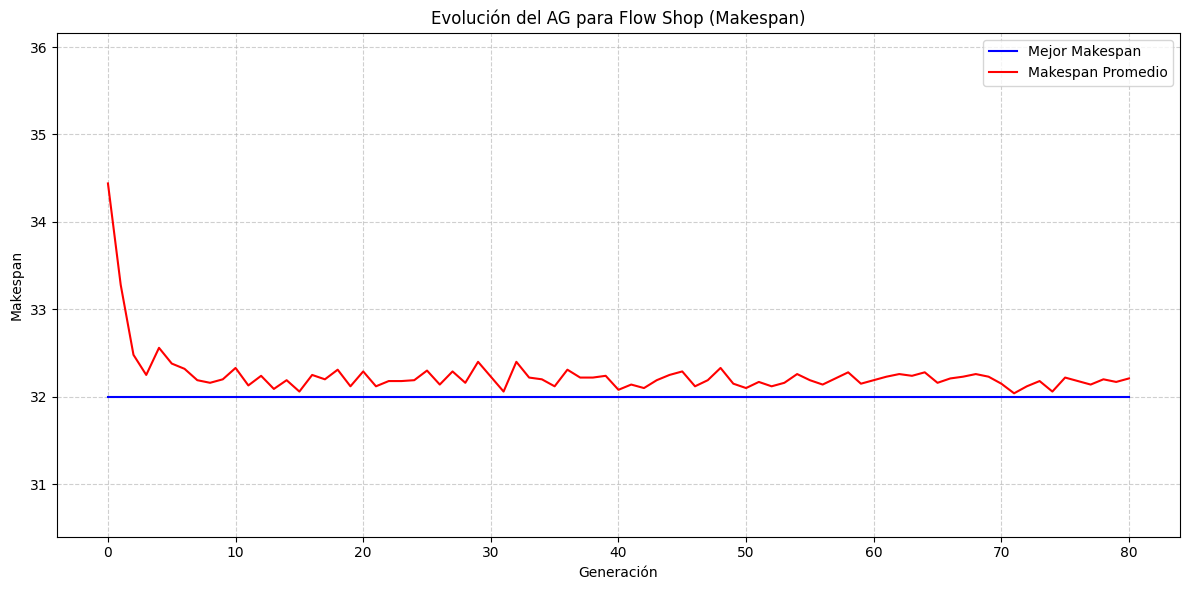

In [ ]:
#@title 7. Visualización de Resultados

# --- 7.1 Gráfico de Evolución del Makespan ---
# Usaremos la misma función que en el ejercicio anterior, adaptando títulos.

def plot_evolution_fsp(logbook, title="Evolución del AG para Flow Shop (Makespan)"):
    """
    Visualiza la evolución del Makespan mínimo y promedio a lo largo
    de las generaciones usando Matplotlib.
    """
    gen = logbook.select("gen")
    min_fitness = logbook.select("min") # Makespan mínimo
    avg_fitness = logbook.select("avg") # Makespan promedio

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(gen, min_fitness, "b-", label="Mejor Makespan")
    ax.plot(gen, avg_fitness, "r-", label="Makespan Promedio")

    ax.set_xlabel("Generación")
    ax.set_ylabel("Makespan")
    ax.set_title(title)
    ax.legend(loc="upper right")
    ax.grid(True, linestyle='--', alpha=0.6)

    # Ajustar límites Y si es necesario
    if min_fitness:
      min_val_overall = min(min_fitness)
      ax.set_ylim(bottom=min_val_overall - max(0.5, min_val_overall*0.05)) # Un poco debajo del mínimo
    if avg_fitness:
        max_val_overall = max(avg_fitness) if gen[0] == 0 else avg_fitness[0] # Usar el inicial si existe
        ax.set_ylim(top=max_val_overall * 1.05) # Un poco encima del promedio inicial


    plt.tight_layout()
    plt.show()

print("--- Gráfico de Evolución ---")
plot_evolution_fsp(evolution_log)



## Gráfico de Evolución

* Muestra claramente que el **Mejor Makespan** (línea azul) encontrado fue de **32.0** y se alcanzó muy temprano (generación 0 o 1) y se mantuvo constante.
* El **Makespan Promedio** (línea roja) bajó inicialmente y luego fluctuó alrededor de 32.1-32.5, indicando que la población exploró soluciones cercanas a la mejor encontrada.


--- Diagrama de Gantt para la Mejor Solución ---


<ipython-input-8-4cac5105822c>:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', num_tareas) # Usar colormap tab10


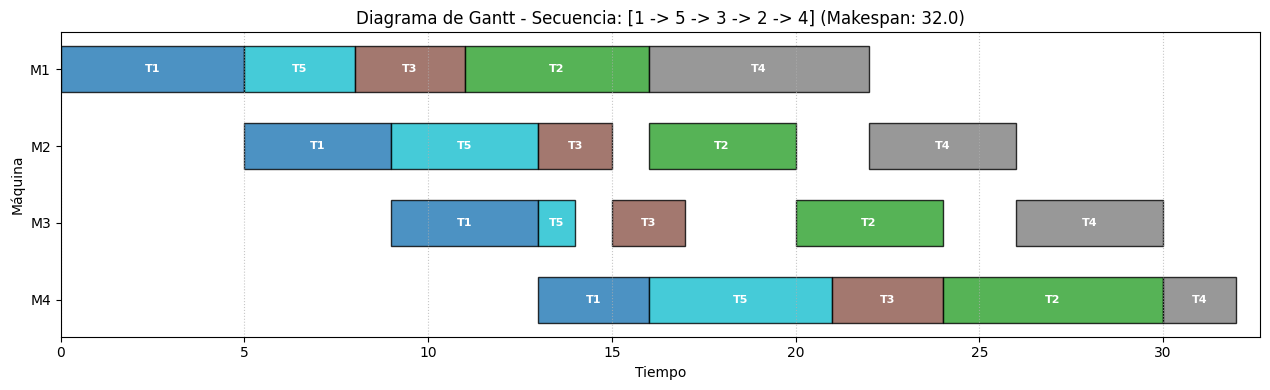

In [ ]:
# --- 7.2 Diagrama de Gantt (Básico) ---
# Crear un diagrama de Gantt ayuda a visualizar la programación.

def calcular_tiempos_gantt(secuencia_tareas, tiempos_proc, num_maquinas, num_tareas):
    """
    Calcula los tiempos de inicio y finalización de cada tarea en cada máquina
    para poder dibujar un diagrama de Gantt.

    Retorna:
        list: Una lista de diccionarios, donde cada diccionario representa una
              operación {tarea, maquina, inicio, duracion, finalizacion}.
    """
    C = np.zeros((num_tareas + 1, num_maquinas)) # Matriz de tiempos de finalización
    S = np.zeros((num_tareas + 1, num_maquinas)) # Matriz de tiempos de inicio (para Gantt)
    gantt_data = []

    for k in range(1, num_tareas + 1):
        idx_tarea_actual = secuencia_tareas[k-1]
        for j in range(num_maquinas):
            tiempo_proc_actual = tiempos_proc[idx_tarea_actual][j]
            tiempo_fin_maq_anterior = C[k][j-1] if j > 0 else 0
            tiempo_fin_tarea_anterior = C[k-1][j] if k > 1 else 0

            # El tiempo de inicio es cuando ambos prerrequisitos se cumplen
            tiempo_inicio = max(tiempo_fin_tarea_anterior, tiempo_fin_maq_anterior)
            tiempo_finalizacion = tiempo_inicio + tiempo_proc_actual

            C[k][j] = tiempo_finalizacion
            S[k][j] = tiempo_inicio

            gantt_data.append({
                'Tarea': f"T{idx_tarea_actual + 1}", # Nombre legible T1, T2...
                'Maquina': f"M{j + 1}",          # Nombre legible M1, M2...
                'Inicio': tiempo_inicio,
                'Duracion': tiempo_proc_actual,
                'Finalizacion': tiempo_finalizacion,
                'indice_maquina': j # Guardar índice para ordenar barras
            })
    return gantt_data

def plot_gantt(gantt_data, makespan, num_maquinas, num_tareas, sequence_readable):
    """Dibuja un diagrama de Gantt básico usando Matplotlib."""
    fig, ax = plt.subplots(figsize=(max(10, makespan * 0.4), max(4, num_maquinas * 0.6)))

    # Crear una paleta de colores para las tareas
    colors = plt.cm.get_cmap('tab10', num_tareas) # Usar colormap tab10

    # Etiquetas de las máquinas en el eje Y (M1, M2, ...)
    machine_labels = [f"M{j+1}" for j in range(num_maquinas)]
    y_pos = np.arange(num_maquinas)

    # Dibujar las barras para cada operación
    for i, job in enumerate(gantt_data):
        tarea_idx = int(job['Tarea'][1:]) - 1 # Extraer índice 0-based de la tarea
        maquina_idx = job['indice_maquina']
        start = job['Inicio']
        duration = job['Duracion']
        # Usar el índice de la máquina para la posición Y
        ax.barh(y=maquina_idx, width=duration, left=start, height=0.6,
                align='center', color=colors(tarea_idx), edgecolor='black', alpha=0.8)
        # Añadir texto (nombre de la tarea) dentro de la barra si hay espacio
        if duration > makespan * 0.03: # Solo si la barra es suficientemente ancha
             ax.text(start + duration / 2, maquina_idx, job['Tarea'],
                     ha='center', va='center', color='white' if colors(tarea_idx)[0] * 0.299 + colors(tarea_idx)[1] * 0.587 + colors(tarea_idx)[2] * 0.114 < 0.6 else 'black', # Contraste
                     fontsize=8, fontweight='bold')

    # Configurar ejes y título
    ax.set_yticks(y_pos)
    ax.set_yticklabels(machine_labels)
    ax.set_xlabel("Tiempo")
    ax.set_ylabel("Máquina")
    # Invertir eje Y para que M1 esté arriba
    ax.invert_yaxis()
    # Poner rejilla vertical
    ax.grid(axis='x', linestyle=':', alpha=0.7)
    # Ajustar límites X
    ax.set_xlim(0, makespan * 1.02)

    sequence_str = " -> ".join(map(str, sequence_readable))
    ax.set_title(f"Diagrama de Gantt - Secuencia: [{sequence_str}] (Makespan: {makespan:.1f})")

    plt.tight_layout()
    plt.show()


print("\n--- Diagrama de Gantt para la Mejor Solución ---")
# Calcular datos para el Gantt de la mejor solución encontrada
gantt_info_mejor = calcular_tiempos_gantt(best_solution_indices, tiempos_procesamiento, m, n)
mejor_makespan = best_solution_indices.fitness.values[0]
mejor_secuencia_legible = [i + 1 for i in best_solution_indices]

# Dibujar el Gantt
plot_gantt(gantt_info_mejor, mejor_makespan, m, n, mejor_secuencia_legible)



## Diagrama de Gantt (Mejor Secuencia: [1 -> 5 -> 3 -> 2 -> 4])

* Este gráfico visualiza la programación resultante de la **mejor secuencia** encontrada por el AG.
* Se puede ver el orden en que las tareas (**T1, T5, T3, T2, T4**) pasan por las máquinas (**M1 a M4**).
* Los espacios en blanco entre algunas barras representan **tiempos de espera** (idle time), ya sea porque una máquina está esperando a que termine la tarea anterior en esa máquina, o porque una tarea está esperando a que la máquina se libere.
* La barra que termina más a la derecha (**T4 en M4**) define el **Makespan**, que según el título y el eje X, es **32.0**.


--- (Comparación) Diagrama de Gantt para Secuencia PDF [1, 2, 3, 4, 5] ---


<ipython-input-8-4cac5105822c>:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', num_tareas) # Usar colormap tab10


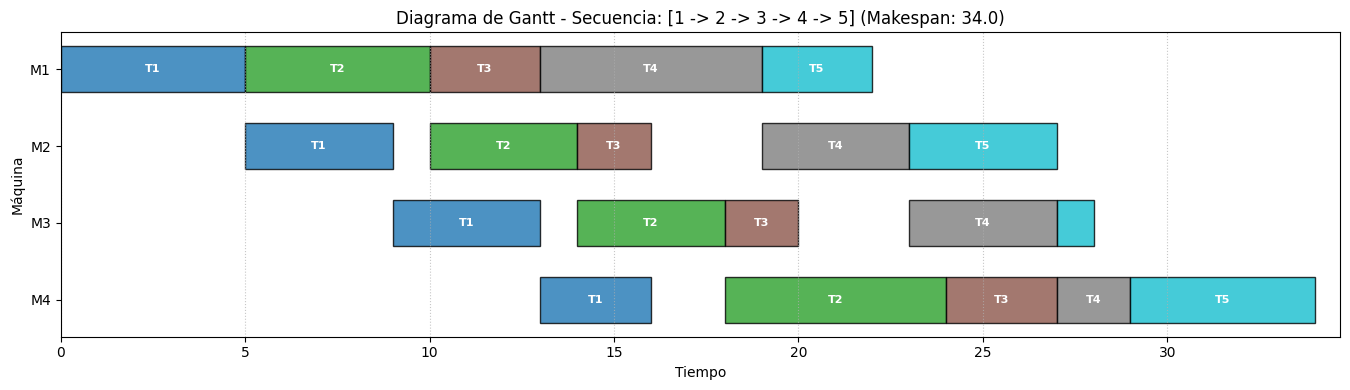

In [ ]:
# (Opcional) Dibujar Gantt para la secuencia original del PDF (1-2-3-4-5) para comparar
print("\n--- (Comparación) Diagrama de Gantt para Secuencia PDF [1, 2, 3, 4, 5] ---")
secuencia_pdf = [0, 1, 2, 3, 4]
gantt_info_pdf = calcular_tiempos_gantt(secuencia_pdf, tiempos_procesamiento, m, n)
makespan_pdf = 34.0 # Ya lo calculamos antes
secuencia_pdf_legible = [i + 1 for i in secuencia_pdf]
plot_gantt(gantt_info_pdf, makespan_pdf, m, n, secuencia_pdf_legible)

## Diagrama de Gantt (Secuencia PDF: [1 -> 2 -> 3 -> 4 -> 5])

* Este gráfico muestra la programación para la **secuencia original** del ejemplo.
* Comparándolo con el Gantt anterior, se puede **visualmente apreciar** que esta programación termina más tarde (en **34.0**). Se nota, por ejemplo, que **T5 en M4** termina notablemente después que **T4 en M4** en el gráfico anterior.
* Sirve como una excelente comparación para entender por qué la secuencia encontrada por el AG es mejor (produce un **Makespan menor**).

## Explicación del Código de Gantt

**Función `calcular_tiempos_gantt`:**
* Similar a `calcular_makespan`, pero además de calcular los tiempos de finalización (`C`), también calcula y guarda los tiempos de **inicio** (`S`) de cada operación.
* Devuelve una lista de diccionarios, donde cada diccionario contiene la información necesaria para dibujar una barra en el Gantt (`Tarea`, `Maquina`, `Inicio`, `Duracion`).

**Función `plot_gantt`:**
* Configura la figura de Matplotlib.
* Define una paleta de colores para distinguir las tareas.
* Establece las etiquetas del eje Y (M1, M2, etc.).
* Itera sobre los datos calculados por `calcular_tiempos_gantt`.
* Para cada operación, dibuja una barra horizontal (`ax.barh`) en la fila correspondiente a la máquina, comenzando en `Inicio` y con ancho `Duracion`.
* Añade el nombre de la tarea dentro de la barra si cabe.
* Configura los ejes, título, rejilla, etc.
* Muestra el gráfico.

**Llamadas:**
* Se llama a `plot_gantt` para la mejor secuencia encontrada por el AG y, opcionalmente, para la secuencia original del PDF para poder comparar visualmente las programaciones.

#8. Interpretación de los Resultados Finales (Flow Shop)

El algoritmo genético ha finalizado la búsqueda de la mejor secuencia de tareas para minimizar el tiempo total de producción (Makespan). Los resultados obtenidos en las secciones anteriores se interpretan de la siguiente manera:

1.  **Convergencia del Algoritmo (Gráfico de Evolución):**
    *   El gráfico "Evolución del AG para Flow Shop (Makespan)" muestra cómo progresó la búsqueda a lo largo de las generaciones.
    *   La **línea azul (`Mejor Makespan`)** descendió rápidamente hasta el valor `32.0` en las primeras generaciones y se mantuvo constante. Esto indica que el algoritmo encontró una solución con este Makespan óptimo (o muy cercano al óptimo) muy pronto y no pudo hallar una secuencia estrictamente mejor en las generaciones posteriores.
    *   La **línea roja (`Makespan Promedio`)** muestra que, aunque la población en general mejoró (redujo su Makespan promedio), se mantuvo ligeramente por encima del mínimo, lo cual es típico en los AG.

2.  **Mejor Solución Encontrada:**
    *   La salida de texto de la ejecución confirmó que el `Mejor Makespan encontrado` fue **`32.0`**.
    *   La secuencia de tareas asociada a este Makespan es **`[1 -> 5 -> 3 -> 2 -> 4]`** (representada internamente como `[0, 4, 2, 1, 3]`). Esta es la secuencia que el algoritmo propone como la más eficiente.

3.  **Visualización con Diagramas de Gantt:**
    *   El primer diagrama de Gantt visualiza la programación de las tareas siguiendo la **mejor secuencia encontrada (`[1 -> 5 -> 3 -> 2 -> 4]`)**. Se puede observar cómo se distribuyen las tareas en el tiempo a través de las cuatro máquinas. La finalización de la última operación (T4 en M4) marca el Makespan de `32.0`. Los espacios en blanco representan tiempos de inactividad de las máquinas o esperas de las tareas.
    *   El segundo diagrama de Gantt muestra la programación para la **secuencia original del ejemplo (`[1 -> 2 -> 3 -> 4 -> 5]`)**. Comparando ambos gráficos, es evidente que la programación de la secuencia original termina más tarde (en `34.0`). Esto demuestra visualmente la mejora obtenida por el algoritmo genético al encontrar una secuencia más eficiente.

**En Conclusión:** El algoritmo genético ha sido capaz de explorar diferentes ordenamientos de las tareas y ha identificado una secuencia (`[1 -> 5 -> 3 -> 2 -> 4]`) que reduce el tiempo total de producción (Makespan) de 34.0 (secuencia original) a 32.0. Las visualizaciones ayudan a entender tanto el proceso de convergencia del algoritmo como la diferencia práctica entre las programaciones resultantes.